# 05. Batch Inference — GreenSpace CNN

Run the trained model on unseen images and export predictions to CSV.

**Prerequisites:**
1. Cache images locally first:
   ```bash
   python scripts/cache_drive_folder.py --folder-id 1C5pkrcuuciTZyLPwhQqpvPZwWJ7fMBzI
   ```
2. A trained model under `models/runs/<RUN_TAG>/`

**Outputs:**
- `predictions/predictions_<RUN_TAG>.csv` — one row per image, all head outputs as columns
- Summary statistics and comparison to training distribution

In [4]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path('../').resolve()))
from src.label_schema import resolve_label_cols

# --- Toggle: manually load a specific model file ---
USE_MANUAL_MODEL = True
MANUAL_MODEL_PATH = '../models/runs/20260321_214623/best_mcmae_20260321_214623.keras'

# --- Limit images for testing (set None for full run) ---
LIMIT = None

# --- Load model ---
if USE_MANUAL_MODEL:
    model_path = Path(MANUAL_MODEL_PATH)
    assert model_path.exists(), f'Model not found: {model_path}'
    model = tf.keras.models.load_model(str(model_path), compile=False)
    # Infer RUN_TAG from path
    RUN_TAG = model_path.parent.name
    print('Loaded MANUAL model:', model_path.name)
else:
    # Auto-resolve: pick the most recently modified run folder
    runs_root = Path('../models/runs')
    RUN_TAG = globals().get('RUN_TAG', None)
    if RUN_TAG is None:
        assert runs_root.exists(), f'Missing runs directory: {runs_root}'
        run_dirs = sorted(
            [p for p in runs_root.iterdir() if p.is_dir()],
            key=lambda p: p.stat().st_mtime,
            reverse=True,
        )
        assert run_dirs, f'No run folders found in {runs_root}'
        run_dir = run_dirs[0]
        RUN_TAG = run_dir.name
    else:
        run_dir = runs_root / RUN_TAG
    candidates = sorted(run_dir.glob('best_*.keras')) + sorted(run_dir.glob('final_*.keras'))
    assert candidates, f'No .keras model found in {run_dir}'
    model_path = candidates[0]
    model = tf.keras.models.load_model(str(model_path), compile=False)
    print('Loaded model:', model_path.name)

print('RUN_TAG:', RUN_TAG)

# --- Locate cached inference images ---
INFERENCE_CACHE = Path('../data/cache/inference_images')
assert INFERENCE_CACHE.exists(), (
    f'Missing {INFERENCE_CACHE}. Run:\n'
    '  python scripts/cache_drive_folder.py --folder-id 1C5pkrcuuciTZyLPwhQqpvPZwWJ7fMBzI'
)

image_paths = sorted(INFERENCE_CACHE.glob('*.jpg')) + sorted(INFERENCE_CACHE.glob('*.jpeg')) + sorted(INFERENCE_CACHE.glob('*.png'))
if LIMIT:
    image_paths = image_paths[:LIMIT]
    print(f'LIMIT={LIMIT} — using {len(image_paths)} of {len(list(INFERENCE_CACHE.glob("*.jpg")))} cached images')
else:
    print(f'Found {len(image_paths)} cached images')

# --- Load training split for comparison later ---
train_csv = Path('../data/processed/splits/train.csv')
assert train_csv.exists(), 'Missing train.csv — run notebook 02 first'
train_df = pd.read_csv(train_csv)

EXCLUDE_BINARY_LABELS = ['gardens_p']  # must match notebook 03
_schema = resolve_label_cols(train_df)
binary_cols   = [c for c in _schema['binary_cols'] if c not in EXCLUDE_BINARY_LABELS]
bin_names     = [c[:-2] for c in binary_cols]

Loaded MANUAL model: best_mcmae_20260321_214623.keras
RUN_TAG: 20260321_214623
Found 15019 cached images


In [5]:
# Batch inference — decode images, predict in batches, collect results.
IMG_SIZE = (512, 512)
BATCH_SIZE = 32

# --- Load tuned thresholds from evaluation ---
THRESHOLD_CSV = Path('../monitoring_output/runs/20260322_073929/thresholds_best_mcmae.csv')
assert THRESHOLD_CSV.exists(), f'Missing thresholds: {THRESHOLD_CSV}'
thresh_df = pd.read_csv(THRESHOLD_CSV)
thresholds = dict(zip(thresh_df['label'], thresh_df['best_threshold']))
print('Loaded tuned thresholds:')
for label, t in thresholds.items():
    print(f'  {label:<30} {t:.4f}')

def decode_and_resize(path):
    img = tf.io.read_file(path)
    img = tf.io.decode_jpeg(img, channels=3)
    img = tf.cast(img, tf.float32) / 255.0
    return img

# Build tf.data pipeline from cached paths (absolute paths for tf.io.read_file)
path_strings = [str(p.resolve()) for p in image_paths]
ds = (
    tf.data.Dataset.from_tensor_slices(path_strings)
    .map(decode_and_resize, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print(f'Running inference on {len(image_paths)} images (batch_size={BATCH_SIZE})...')
preds = model.predict(ds, verbose=1)

# preds is a list of 4 arrays: [bin_head, shade_head, score_head, veg_head]
pred_bin   = preds[0]  # (N, len(bin_names)) sigmoid probabilities
pred_shade = preds[1]  # (N, 2) softmax
pred_score = preds[2]  # (N, 5) softmax
pred_veg   = preds[3]  # (N, 5) softmax

print(f'Predictions complete: {pred_bin.shape[0]} images')

# Assemble results into a DataFrame
filenames = [p.name for p in image_paths]

rows = {'image_filename': filenames}

# Binary: probability + hard prediction (0/1) side by side per label
for i, name in enumerate(bin_names):
    rows[f'{name}_prob'] = pred_bin[:, i]
    t = thresholds.get(name, 0.5)
    rows[f'{name}_pred'] = (pred_bin[:, i] >= t).astype(int)

# Shade: class + confidence
rows['shade_class'] = np.where(pred_shade.argmax(axis=1) == 0, 'minimal', 'abundant')
rows['shade_confidence'] = pred_shade.max(axis=1)

# Score: expected value (1–5 scale)
score_values = np.arange(1, 6, dtype=np.float32)
rows['score_ev'] = pred_score @ score_values

# Veg: expected value (1–5 scale)
rows['veg_ev'] = pred_veg @ score_values

pred_df = pd.DataFrame(rows)

# Save CSV
out_dir = Path('../predictions')
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / f'predictions_{RUN_TAG}.csv'
pred_df.to_csv(out_path, index=False)
print(f'Saved {len(pred_df)} predictions to {out_path}')
pred_df.head()

Loaded tuned thresholds:
  sports_field                   0.5365
  multipurpose_open_area         0.4080
  children_s_playground          0.2101
  water_feature                  0.2260
  gardens                        0.2802
  walking_paths                  0.3708
  built_structures               0.3256
  parking_lots                   0.3615
Running inference on 15019 images (batch_size=32)...
470/470 ━━━━━━━━━━━━━━━━━━━━ 595s 1s/step
Predictions complete: 15019 images
Saved 15019 predictions to ../predictions/predictions_20260321_214623.csv


,image_filename,sports_field_prob,sports_field_pred,multipurpose_open_area_prob,multipurpose_open_area_pred,children_s_playground_prob,children_s_playground_pred,water_feature_prob,water_feature_pred,gardens_prob,...,walking_paths_prob,walking_paths_pred,built_structures_prob,built_structures_pred,parking_lots_prob,parking_lots_pred,shade_class,shade_confidence,score_ev,veg_ev
0,USA_NY_00970-0003_1_0-00000_f00_p000.jpg,0.003618,0,0.438936,1,0.004488,0,0.191298,0,0.003131,...,0.387363,1,0.023743,0,0.012589,0,minimal,0.906419,4.635453,1.733566
1,USA_NY_00970-0003_1_1-00000_f01_p000.jpg,0.002256,0,0.357459,0,0.001870,0,0.112170,0,0.001713,...,0.457982,1,0.021273,0,0.006940,0,minimal,0.834040,4.593633,2.195279
2,USA_NY_00970-0003_1_12-00000_f04_p000.jpg,0.007094,0,0.748741,1,0.003284,0,0.172616,0,0.004142,...,0.328653,0,0.018945,0,0.005724,0,minimal,0.522848,4.392928,3.219644
3,USA_NY_00970-0003_1_13-00000_f05_p000.jpg,0.007113,0,0.749070,1,0.002287,0,0.209128,0,0.002862,...,0.392639,1,0.026598,0,0.009593,0,abundant,0.558297,4.231222,3.218678
4,USA_NY_00970-0003_1_14-00000_f06_p000.jpg,0.012096,0,0.807851,1,0.013568,0,0.463510,1,0.007418,...,0.547596,1,0.029682,0,0.019411,0,minimal,0.739673,4.013582,1.691704


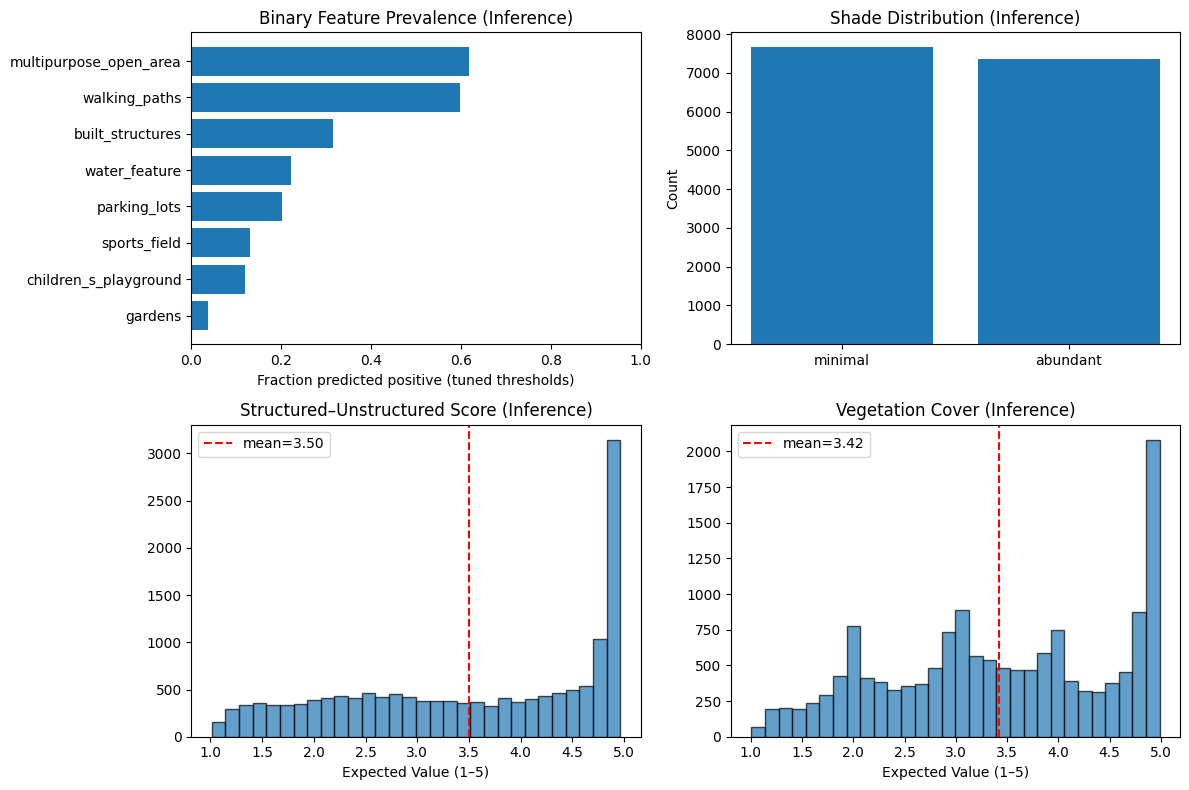

Images: 15019

Binary feature prevalence (tuned thresholds):
  gardens                        3.7%  (threshold=0.2802)
  children_s_playground          12.0%  (threshold=0.2101)
  sports_field                   13.1%  (threshold=0.5365)
  parking_lots                   20.1%  (threshold=0.3615)
  water_feature                  22.1%  (threshold=0.2260)
  built_structures               31.5%  (threshold=0.3256)
  walking_paths                  59.8%  (threshold=0.3708)
  multipurpose_open_area         61.8%  (threshold=0.4080)

Shade: {'minimal': 7664, 'abundant': 7355}
Score EV: mean=3.50, std=1.22
Veg EV:   mean=3.42, std=1.11


In [6]:
# Option 1: Summary statistics across all unseen images

pred_cols = [f'{n}_pred' for n in bin_names]

# Binary feature prevalence (using tuned thresholds from _pred columns)
prevalence = pred_df[pred_cols].mean().sort_values()
prevalence.index = [c.replace('_pred', '') for c in prevalence.index]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# 1a. Binary feature prevalence
ax = axes[0, 0]
ax.barh(prevalence.index, prevalence.values)
ax.set_xlabel('Fraction predicted positive (tuned thresholds)')
ax.set_title('Binary Feature Prevalence (Inference)')
ax.set_xlim(0, 1)

# 1b. Shade distribution
ax = axes[0, 1]
shade_counts = pred_df['shade_class'].value_counts()
ax.bar(shade_counts.index, shade_counts.values)
ax.set_title('Shade Distribution (Inference)')
ax.set_ylabel('Count')

# 1c. Structured score distribution
ax = axes[1, 0]
ax.hist(pred_df['score_ev'], bins=30, edgecolor='black', alpha=0.7)
ax.set_xlabel('Expected Value (1–5)')
ax.set_title('Structured–Unstructured Score (Inference)')
ax.axvline(pred_df['score_ev'].mean(), color='red', linestyle='--', label=f"mean={pred_df['score_ev'].mean():.2f}")
ax.legend()

# 1d. Vegetation distribution
ax = axes[1, 1]
ax.hist(pred_df['veg_ev'], bins=30, edgecolor='black', alpha=0.7)
ax.set_xlabel('Expected Value (1–5)')
ax.set_title('Vegetation Cover (Inference)')
ax.axvline(pred_df['veg_ev'].mean(), color='red', linestyle='--', label=f"mean={pred_df['veg_ev'].mean():.2f}")
ax.legend()

plt.tight_layout()
plt.savefig(out_dir / f'summary_stats_{RUN_TAG}.png', dpi=150, bbox_inches='tight')
plt.show()

# Print key numbers
print(f'Images: {len(pred_df)}')
print(f'\nBinary feature prevalence (tuned thresholds):')
for name, val in prevalence.items():
    t = thresholds.get(name, 0.5)
    print(f'  {name:<30} {val:.1%}  (threshold={t:.4f})')
print(f'\nShade: {dict(shade_counts)}')
print(f'Score EV: mean={pred_df["score_ev"].mean():.2f}, std={pred_df["score_ev"].std():.2f}')
print(f'Veg EV:   mean={pred_df["veg_ev"].mean():.2f}, std={pred_df["veg_ev"].std():.2f}')

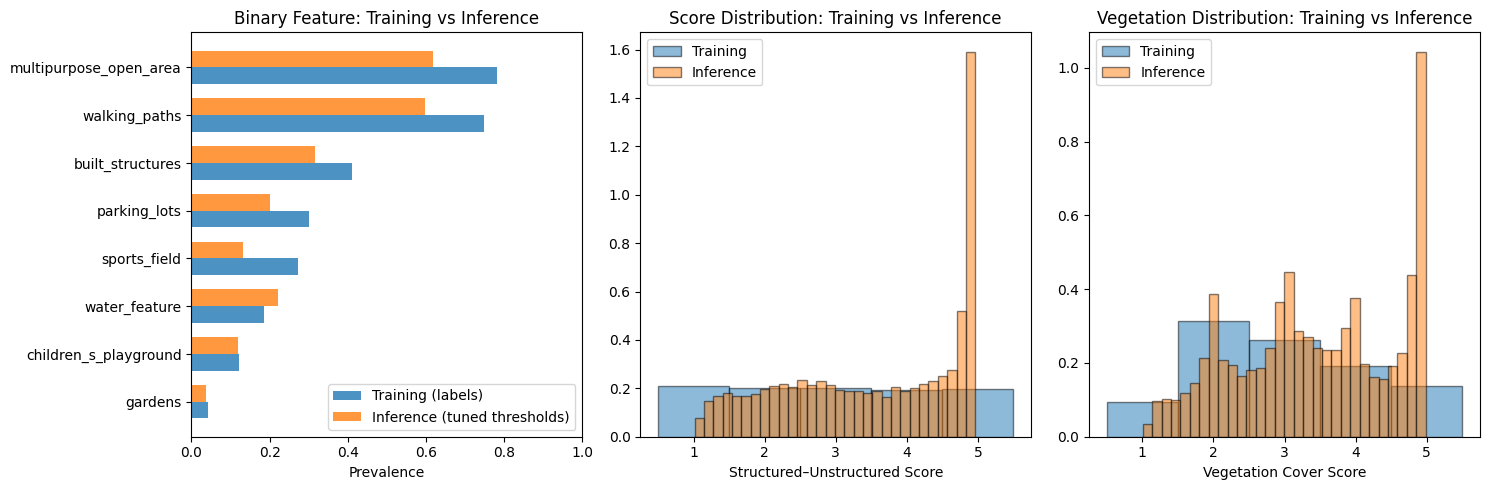

Binary prevalence shift (inference - training):
  multipurpose_open_area         -16.2%
  walking_paths                  -15.0%
  sports_field                   -14.1%
  parking_lots                   -10.0%
  built_structures               -9.5%
  gardens                        -0.4%
  children_s_playground          -0.2%
  water_feature                  +3.4%


In [7]:
# Option 5: Compare inference predictions to training label distribution.
# Large shifts may indicate domain gap between the training set and these unseen images.

# Training: hard binary labels (0/1 from soft >= 0.5 threshold in notebook 02)
hard_bin_cols = [n for n in bin_names if n in train_df.columns]
train_prev = train_df[hard_bin_cols].mean().sort_values()

# Inference: predicted prevalence using tuned thresholds (_pred columns)
infer_prev = pred_df[[f'{n}_pred' for n in hard_bin_cols]].mean()
infer_prev.index = [c.replace('_pred', '') for c in infer_prev.index]
infer_prev = infer_prev.reindex(train_prev.index)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 5a. Binary prevalence side-by-side
ax = axes[0]
x = np.arange(len(train_prev))
w = 0.35
ax.barh(x - w/2, train_prev.values, height=w, label='Training (labels)', alpha=0.8)
ax.barh(x + w/2, infer_prev.values, height=w, label='Inference (tuned thresholds)', alpha=0.8)
ax.set_yticks(x)
ax.set_yticklabels(train_prev.index)
ax.set_xlabel('Prevalence')
ax.set_title('Binary Feature: Training vs Inference')
ax.legend()
ax.set_xlim(0, 1)

# 5b. Score EV comparison
ax = axes[1]
if 'score_class' in train_df.columns:
    train_score = train_df['score_class'].dropna()
    ax.hist(train_score, bins=np.arange(0.5, 6.5, 1), alpha=0.5, label='Training', density=True, edgecolor='black')
ax.hist(pred_df['score_ev'], bins=30, alpha=0.5, label='Inference', density=True, edgecolor='black')
ax.set_xlabel('Structured–Unstructured Score')
ax.set_title('Score Distribution: Training vs Inference')
ax.legend()

# 5c. Veg EV comparison
ax = axes[2]
if 'veg_class' in train_df.columns:
    train_veg = train_df['veg_class'].dropna()
    ax.hist(train_veg, bins=np.arange(0.5, 6.5, 1), alpha=0.5, label='Training', density=True, edgecolor='black')
ax.hist(pred_df['veg_ev'], bins=30, alpha=0.5, label='Inference', density=True, edgecolor='black')
ax.set_xlabel('Vegetation Cover Score')
ax.set_title('Vegetation Distribution: Training vs Inference')
ax.legend()

plt.tight_layout()
plt.savefig(out_dir / f'train_vs_inference_{RUN_TAG}.png', dpi=150, bbox_inches='tight')
plt.show()

# Print shift summary
print('Binary prevalence shift (inference - training):')
shift = infer_prev - train_prev
for name, val in shift.sort_values().items():
    direction = '+' if val > 0 else ''
    print(f'  {name:<30} {direction}{val:.1%}')